# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

loaded 810 photons
Moffat FWHM = 4.52 px


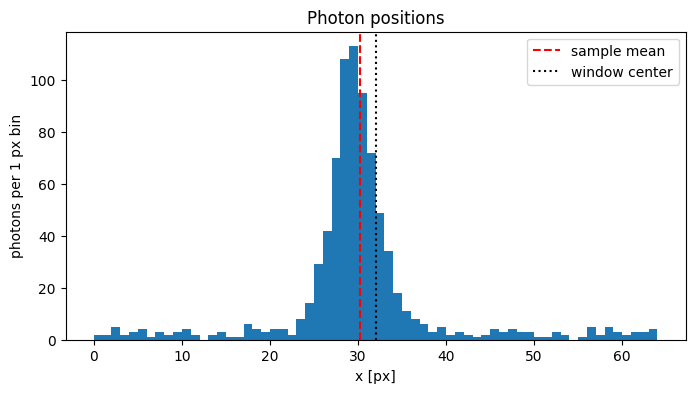

sample mean: x0 = 30.218 +/- 0.312 px
s = 8.89 px
Moffat-only std would be 2.83 px


In [1]:
# Part 1
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy import stats
from scipy.integrate import trapezoid

netid = 'ym31'
data = np.genfromtxt(f'../../labs/02/data/{netid}.csv', delimiter=',', names=True)
x = data['x']
N = len(x)
L = 64.0
beta_known = 2.5
r0_known = 4.0
print("loaded", N, "photons")

# Moffat FWHM, for the bin width
fwhm = 2 * r0_known * np.sqrt(2**(1 / beta_known) - 1)
print(f"Moffat FWHM = {fwhm:.2f} px")

mean_hat = x.mean()
mean_err = x.std(ddof=1) / np.sqrt(N)

bins = np.arange(0, L + 1, 1.0)
plt.figure(figsize=(8, 4))
plt.hist(x, bins=bins)
plt.axvline(mean_hat, color='red', ls='--', label='sample mean')
plt.axvline(L / 2, color='black', ls=':', label='window center')
plt.xlabel('x [px]')
plt.ylabel('photons per 1 px bin')
plt.title('Photon positions')
plt.legend()
plt.show()

print(f"sample mean: x0 = {mean_hat:.3f} +/- {mean_err:.3f} px")
print(f"s = {x.std(ddof=1):.2f} px")
print(f"Moffat-only std would be {r0_known / np.sqrt(2 * beta_known - 3):.2f} px")

**ANSWER (a few sentences):**

I went with 1 px bins. The Moffat FWHM is about 4.5 px, so that gives 4 or 5 bins across the core, and the bins at the peak still have around 100 photons each. The sample mean gives $\hat{x}_0 = 30.22 \pm 0.31$ px.

Yes, it's biased. The mean has no idea which photons came from the star, so it measures the mean of everything together. The background is uniform, so its mean is the middle of the window (32), and that pulls the answer toward 32. How big the pull is depends on how much background there is and how far the star is from the center. My peak looks like it's around 29.6, so the mean gets pulled up by about $f_{\rm bg}(32 - x_0) \approx 0.5$ px. Getting more photons wouldn't help, it would just make the error bar smaller around the wrong answer.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [2]:
# Part 2
def moffat(x, x0, beta=beta_known, r0=r0_known):
    lnnorm = gammaln(beta) - np.log(r0 * np.sqrt(np.pi)) - gammaln(beta - 0.5)
    return np.exp(lnnorm) * (1 + ((x - x0) / r0)**2)**(-beta)

def pdf_mix(x, x0, f, beta=beta_known, r0=r0_known):
    return f / L + (1 - f) * moffat(x, x0, beta, r0)

def nll(theta, x, beta=beta_known, r0=r0_known):
    x0, f = theta
    if f < 0 or f >= 1 or x0 <= 0 or x0 >= L:
        return np.inf
    return -np.sum(np.log(pdf_mix(x, x0, f, beta, r0)))

def sigma_clip_mean(x, k=3.0, max_iter=100):
    c = np.median(x)
    s = 1.4826 * np.median(np.abs(x - c))
    keep = np.abs(x - c) < k * s
    for _ in range(max_iter):
        c = x[keep].mean()
        s = x[keep].std(ddof=1)
        new = np.abs(x - c) < k * s
        if np.array_equal(new, keep):
            break
        keep = new
    return c, s / np.sqrt(keep.sum()), keep

def hessian(fun, p, h):
    p = np.asarray(p, float)
    n = len(p)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.eye(n)[i] * h[i]
            ej = np.eye(n)[j] * h[j]
            H[i, j] = (fun(p + ei + ej) - fun(p + ei - ej)
                       - fun(p - ei + ej) + fun(p - ei - ej)) / (4 * h[i] * h[j])
    return H

def optimize_mle(x, start, beta=beta_known, r0=r0_known, nllfun=nll):
    r = minimize(nllfun, start, args=(x, beta, r0), method='Nelder-Mead',
                 options={'xatol': 1e-6, 'fatol': 1e-9, 'maxiter': 2000})
    return r.x, r.fun

def fit_mle(x, start=None, beta=beta_known, r0=r0_known, nllfun=nll):
    if start is None:
        start = [np.median(x), 0.2]
    th, fun = optimize_mle(x, start, beta, r0, nllfun)
    H = hessian(lambda p: nllfun(p, x, beta, r0), th, [1e-3, 1e-4])
    return th, np.linalg.inv(H), fun

med_hat = np.median(x)
print("median:", round(med_hat, 3))

# 2. sigma-clipped mean
for k in [2.5, 3.0, 3.5]:
    c, e, keep = sigma_clip_mean(x, k)
    print(f"clip k={k}: x0 = {c:.3f} +/- {e:.3f}, kept {keep.sum()} of {N}")
clip_hat, clip_err, keep = sigma_clip_mean(x, 3.0)

# 3. MLE
theta_mle, cov_mle, nll_min = fit_mle(x)
for s0 in (15, 45):
    print("start x0 =", s0, "->", np.round(optimize_mle(x, [s0, 0.2])[0], 4))
x0_mle, f_mle = theta_mle
sx0_mle, sf_mle = np.sqrt(np.diag(cov_mle))
corr = cov_mle[0, 1] / (sx0_mle * sf_mle)
print(f"MLE: x0 = {x0_mle:.3f} +/- {sx0_mle:.3f}")
print(f"MLE: f_bg = {f_mle:.4f} +/- {sf_mle:.4f}")
print(f"correlation = {corr:.3f}")

median: 29.618
clip k=2.5: x0 = 29.595 +/- 0.090, kept 645 of 810
clip k=3.0: x0 = 29.716 +/- 0.104, kept 681 of 810
clip k=3.5: x0 = 29.731 +/- 0.117, kept 700 of 810
start x0 = 15 -> [29.5917  0.202 ]
start x0 = 45 -> [29.5917  0.202 ]
MLE: x0 = 29.592 +/- 0.100
MLE: f_bg = 0.2020 +/- 0.0172
correlation = -0.016


CRB from the 2x2 inverse: sigma_x0 >= 0.0976 px, sigma_f >= 0.0171
CRB from the x0 term alone: 0.0976 px
3x CRB limit on sigma_x0: 0.293 px

estimator, x0, sigma, sigma/CRB
sample mean  30.218 0.312 3.2
median       29.618 0.115 1.18
clipped k=3  29.716 0.104 1.06
mixture MLE  29.592 0.1 1.03


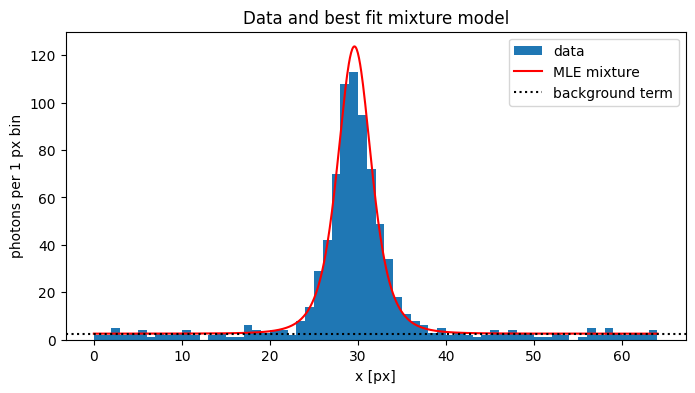

In [3]:
# Cramer-Rao bound
def fisher_matrix(x0, f, beta=beta_known, r0=r0_known):
    g = np.linspace(0, L, 400001)
    m = moffat(g, x0, beta, r0)
    p = f / L + (1 - f) * m
    u = (g - x0) / r0
    dp_dx0 = (1 - f) * m * 2 * beta * u / r0 / (1 + u**2)
    dp_df = 1 / L - m
    I = np.zeros((2, 2))
    I[0, 0] = trapezoid(dp_dx0**2 / p, g)
    I[1, 1] = trapezoid(dp_df**2 / p, g)
    I[0, 1] = trapezoid(dp_dx0 * dp_df / p, g)
    I[1, 0] = I[0, 1]
    return I

I1 = fisher_matrix(x0_mle, f_mle)
crb_cov = np.linalg.inv(I1) / N
crb_x0, crb_f = np.sqrt(np.diag(crb_cov))
crb_x0_only = 1 / np.sqrt(N * I1[0, 0])
print(f"CRB from the 2x2 inverse: sigma_x0 >= {crb_x0:.4f} px, sigma_f >= {crb_f:.4f}")
print(f"CRB from the x0 term alone: {crb_x0_only:.4f} px")
print(f"3x CRB limit on sigma_x0: {3 * crb_x0:.3f} px")

med_err = 1 / (2 * pdf_mix(med_hat, x0_mle, f_mle) * np.sqrt(N))

print()
print("estimator, x0, sigma, sigma/CRB")
print("sample mean ", round(mean_hat, 3), round(mean_err, 3), round(mean_err / crb_x0, 2))
print("median      ", round(med_hat, 3), round(med_err, 3), round(med_err / crb_x0, 2))
print("clipped k=3 ", round(clip_hat, 3), round(clip_err, 3), round(clip_err / crb_x0, 2))
print("mixture MLE ", round(x0_mle, 3), round(sx0_mle, 3), round(sx0_mle / crb_x0, 2))

g = np.linspace(0, L, 1000)
plt.figure(figsize=(8, 4))
plt.hist(x, bins=bins, label='data')
plt.plot(g, N * pdf_mix(g, x0_mle, f_mle), color='red', label='MLE mixture')
plt.axhline(N * f_mle / L, color='black', ls=':', label='background term')
plt.xlabel('x [px]')
plt.ylabel('photons per 1 px bin')
plt.title('Data and best fit mixture model')
plt.legend()
plt.show()

**FINAL ANSWER:** $x_0 = $ 29.59 $\pm$ 0.10 px , $f_{\rm bg} = $ 0.202 $\pm$ 0.017 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.098 px

**Justification and uncertainty method (a short paragraph):**

I'm going with the mixture MLE. It's the only one of the four that actually has the background in the model, and it gives me $f_{\rm bg}$ at the same time. In the Part 3 simulations it comes out unbiased and its scatter is basically at the bound (std/CRB = 1.01). For the uncertainties I used the curvature of the log-likelihood at the peak: I took the 2×2 Hessian of $-\ln L$ with finite differences (the observed information), inverted it, and took the square root of the diagonal. I trust these error bars because in the simulations they cover the truth 67% of the time for $x_0$ and 69% for $f_{\rm bg}$, and because 0.100 px is 1.03× the bound, so it isn't too good to be true and it's under the 3× limit of 0.29 px.

For the others: the mean (30.22 ± 0.31) is biased and its error bar is 3.2× the bound. The median (29.62 ± 0.12) is better but still gets pulled toward 32 a little. The clipped mean with k = 3 (29.72 ± 0.10) is about 1.2σ higher than the MLE and it moves by 0.1 px when I change k. I used k = 3 because that keeps 99.7% of a Gaussian core.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

I wrote this after Part 2 had run on my data, but before running any of the simulations below. All simulations use N = 810. If a simulated photon lands outside [0, 64] it gets thrown away and redrawn.

1. **Closure.** Simulate one dataset with a truth that I pick, far from my own fit (x0 = 20, f_bg = 0.30), and run the same `fit_mle` on it. Also try starting the optimizer from x0 = 5, 32, 58.
   *Failure:* x0 or f_bg is more than 3σ from the truth, or different starts give different answers.

2. **Bias and efficiency.** Simulate lots of datasets at my best-fit values and run all four estimators on each one. What I expect: mean bias = f_bg(32 − x0), so about +0.48 px. Median and clipped mean biased in the same direction but less. MLE unbiased, with std within a few % of the bound.
   *Failure:* MLE bias more than 3× its Monte Carlo standard error, or MLE std more than 10% above the CRB. Also if any estimator is unbiased and clearly below the CRB, because that would mean my Fisher integral or my simulator is wrong.

3. **Coverage.** Using the same simulations, count how often |x̂0 − truth| < the Hessian σ that fit reported. Same thing for f_bg.
   *Failure:* MLE coverage outside 0.65–0.71 (too high or too low).

4. **Sensitivity.** (a) Refit my real data with β and r0 each wrong by ±10%. *Failure:* x0 moves by more than 0.5σ. (b) Lost photons: refit with the star term renormalized over the window. *Failure:* x0 or f_bg moves by more than 0.1σ.

In [4]:
# Part 3b
rng = np.random.default_rng(457)
nu_t = 2 * beta_known - 1

def simulate(x0, f, n, rng, beta=beta_known, r0=r0_known):
    nu = 2 * beta - 1
    out = np.empty(0)
    while len(out) < n:
        m = n - len(out)
        is_bg = rng.random(m) < f
        bg = rng.uniform(0, L, m)
        star = x0 + r0 / np.sqrt(nu) * rng.standard_t(nu, m)
        d = np.where(is_bg, bg, star)
        out = np.concatenate([out, d[(d >= 0) & (d <= L)]])
    return out

# check 1: closure
x0_true = 20.0
f_true = 0.30
d = simulate(x0_true, f_true, N, rng)
th, cov, _ = fit_mle(d)
e = np.sqrt(np.diag(cov))
print("closure, truth x0 =", x0_true, " f =", f_true)
print(f"x0 = {th[0]:.3f} +/- {e[0]:.3f}, off by {(th[0] - x0_true) / e[0]:.2f} sigma")
print(f"f = {th[1]:.4f} +/- {e[1]:.4f}, off by {(th[1] - f_true) / e[1]:.2f} sigma")
for s0 in (5, 32, 58):
    th_s, fun_s = optimize_mle(d, [s0, 0.5])
    print(f"start x0 = {s0}: x0 = {th_s[0]:.3f}, f = {th_s[1]:.3f}, lnL = {-fun_s:.2f}")

closure, truth x0 = 20.0  f = 0.3
x0 = 19.906 +/- 0.104, off by -0.90 sigma
f = 0.2924 +/- 0.0191, off by -0.40 sigma
start x0 = 5: x0 = 6.564, f = 1.000, lnL = -3368.70
start x0 = 32: x0 = 19.906, f = 0.292, lnL = -2634.12
start x0 = 58: x0 = 19.906, f = 0.292, lnL = -2634.12


truth x0 = 29.59  f = 0.2
CRB sigma_x0 = 0.0974
predicted mean bias f(32-x0) = 0.482

estimator: bias +/- error, std, std/CRB
mean: +0.4866 +/- 0.0098, 0.3085, 3.17
median: +0.0470 +/- 0.0037, 0.1184, 1.21
clip: -0.0023 +/- 0.0035, 0.1107, 1.14
mle: -0.0050 +/- 0.0031, 0.0989, 1.01
f_bg: -0.0008 +/- 0.0005, 0.0165, 0.97


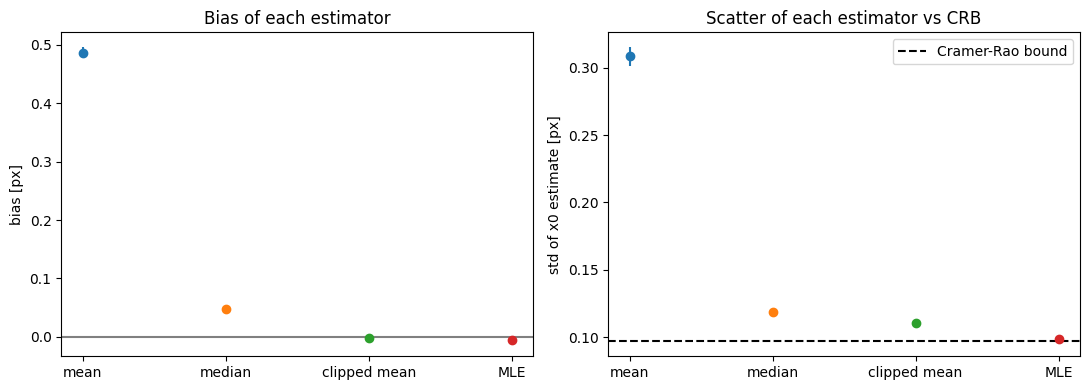

coverage, expect 0.683 +/- 0.015
MLE x0:       0.673
MLE f_bg:     0.691
mean:         0.265
clipped mean: 0.627


In [5]:
# checks 2 and 3: Monte Carlo
nsim = 1000
x0t = round(x0_mle, 2)
ft = round(f_mle, 2)

names = ['mean', 'median', 'clip', 'mle']
est = {'mean': np.zeros(nsim), 'median': np.zeros(nsim), 'clip': np.zeros(nsim), 'mle': np.zeros(nsim)}
err = {'mean': np.zeros(nsim), 'clip': np.zeros(nsim), 'mle': np.zeros(nsim)}
f_est = np.zeros(nsim)
f_err = np.zeros(nsim)
for i in range(nsim):
    d = simulate(x0t, ft, N, rng)
    th, cov, _ = fit_mle(d)
    c, ce, _ = sigma_clip_mean(d, 3.0)
    est['mean'][i] = d.mean()
    err['mean'][i] = d.std(ddof=1) / np.sqrt(N)
    est['median'][i] = np.median(d)
    est['clip'][i] = c
    err['clip'][i] = ce
    est['mle'][i] = th[0]
    err['mle'][i] = np.sqrt(cov[0, 0])
    f_est[i] = th[1]
    f_err[i] = np.sqrt(cov[1, 1])

crb_t = np.sqrt(np.diag(np.linalg.inv(fisher_matrix(x0t, ft)) / N))
print("truth x0 =", x0t, " f =", ft)
print(f"CRB sigma_x0 = {crb_t[0]:.4f}")
print(f"predicted mean bias f(32-x0) = {ft * (32 - x0t):.3f}")
print()
print("estimator: bias +/- error, std, std/CRB")
for k in names:
    b = est[k].mean() - x0t
    s = est[k].std(ddof=1)
    print(f"{k}: {b:+.4f} +/- {s / np.sqrt(nsim):.4f}, {s:.4f}, {s / crb_t[0]:.2f}")
b = f_est.mean() - ft
s = f_est.std(ddof=1)
print(f"f_bg: {b:+.4f} +/- {s / np.sqrt(nsim):.4f}, {s:.4f}, {s / crb_t[1]:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, k in enumerate(names):
    b = est[k].mean() - x0t
    s = est[k].std(ddof=1)
    ax[0].errorbar(i, b, yerr=s / np.sqrt(nsim), fmt='o')
    ax[1].errorbar(i, s, yerr=s / np.sqrt(2 * nsim), fmt='o')
ax[0].axhline(0, color='gray')
ax[0].set_ylabel('bias [px]')
ax[0].set_title('Bias of each estimator')
ax[1].axhline(crb_t[0], color='k', ls='--', label='Cramer-Rao bound')
ax[1].set_ylabel('std of x0 estimate [px]')
ax[1].set_title('Scatter of each estimator vs CRB')
ax[1].legend()
for a in ax:
    a.set_xticks(range(4))
    a.set_xticklabels(['mean', 'median', 'clipped mean', 'MLE'])
plt.tight_layout()
plt.show()

# coverage
print("coverage, expect 0.683 +/-", round(np.sqrt(0.683 * 0.317 / nsim), 3))
print("MLE x0:      ", np.mean(np.abs(est['mle'] - x0t) < err['mle']))
print("MLE f_bg:    ", np.mean(np.abs(f_est - ft) < f_err))
print("mean:        ", np.mean(np.abs(est['mean'] - x0t) < err['mean']))
print("clipped mean:", np.mean(np.abs(est['clip'] - x0t) < err['clip']))

In [6]:
# check 4a
print("beta, r0 -> x0 (shift in sigma), f_bg (shift in sigma), change in lnL")
for b_, r_ in [(2.5, 4.0), (2.25, 4.0), (2.75, 4.0), (2.5, 3.6), (2.5, 4.4)]:
    th, cov, fun = fit_mle(x, beta=b_, r0=r_)
    dx = (th[0] - x0_mle) / sx0_mle
    df = (th[1] - f_mle) / sf_mle
    print(f"{b_}, {r_} -> {th[0]:.3f} ({dx:+.2f}), {th[1]:.4f} ({df:+.2f}), {nll_min - fun:+.2f}")

# check 4b: lost photons
t_dist = stats.t(df=nu_t, scale=r0_known / np.sqrt(nu_t))

def nll_trunc(theta, x, beta=beta_known, r0=r0_known):
    x0, f = theta
    if f < 0 or f >= 1 or x0 <= 0 or x0 >= L:
        return np.inf
    inside = t_dist.cdf(L - x0) - t_dist.cdf(-x0)
    return -np.sum(np.log(f / L + (1 - f) * moffat(x, x0) / inside))

th_t, cov_t, _ = fit_mle(x, nllfun=nll_trunc)
lost = 1 - (t_dist.cdf(L - x0_mle) - t_dist.cdf(-x0_mle))
print()
print(f"fraction of star light outside the window: {lost:.2e}")
print(f"truncated refit: x0 = {th_t[0]:.4f}, f = {th_t[1]:.4f}")
print(f"shift in x0: {(th_t[0] - x0_mle) / sx0_mle:.4f} sigma")
print(f"shift in f: {(th_t[1] - f_mle) / sf_mle:.4f} sigma")

beta, r0 -> x0 (shift in sigma), f_bg (shift in sigma), change in lnL
2.5, 4.0 -> 29.592 (+0.00), 0.2020 (+0.00), +0.00
2.25, 4.0 -> 29.596 (+0.05), 0.1891 (-0.75), +0.74
2.75, 4.0 -> 29.586 (-0.05), 0.2138 (+0.68), -3.99
2.5, 3.6 -> 29.579 (-0.13), 0.2149 (+0.75), -7.08
2.5, 4.4 -> 29.603 (+0.11), 0.1915 (-0.61), +1.16

fraction of star light outside the window: 9.42e-05
truncated refit: x0 = 29.5917, f = 0.2020
shift in x0: -0.0003 sigma
shift in f: -0.0004 sigma


**WHAT THE CHECKS FOUND:**

**1. Closure:** The numbers passed. I got 19.91 ± 0.10 and 0.292 ± 0.019 for a truth of (20, 0.30), which is −0.9σ and −0.4σ. But the start at x0 = 5 ended up at x0 = 6.6 with f_bg = 1, and by the rule I wrote down that counts as a failure. I looked into it and it's the fit saying everything is background, where x0 doesn't mean anything. Its lnL is 735 below the real maximum so it isn't a real second peak. So the optimizer has to start near the star. I start it at the median, and the starts at 32 and 58 give the same answer.

**2. Bias and efficiency:** The mean bias came out +0.487 ± 0.010 px and I predicted +0.482. The median is +0.047, small but real. The MLE bias is −0.005 ± 0.003, so consistent with zero, and std/CRB = 1.01. f_bg is unbiased too with std/CRB = 0.97, which is within the ~2% noise you get from 1000 sims. The thing I got wrong: I predicted the clipped mean would be biased toward 32 and it isn't (−0.002 ± 0.004). It is 14% above the bound though.

**3. Coverage:** The MLE got 0.673 for x0 and 0.691 for f_bg (expected 0.683 ± 0.015), so it passed. The mean only covers 27% because of the bias. The clipped mean covers 63%, which is a little low.

**4. Sensitivity:** With β or r0 off by 10%, x0 moves 0.13σ at most, so that passed. f_bg moves more, up to 0.75σ, so my σ_f is only right if β and r0 really are known. Lost photons: the star only loses $9\times10^{-5}$ of its light at my x0 and the truncated refit doesn't move anything (< 0.001σ), so that passed too.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I used Claude Code for this lab. Basically the AI wrote everything first: the code cells, the first drafts of the written answers, and the verification plan (the plan was written before any of the Part 3 simulations were run). It followed what we did in the Day 5 lecture (curvature for the error bar, the Fisher integral done numerically, coverage from simulations). Then I went through all of it, and everything in here is its version with adjustments on top, mostly made by me telling it what to change. Later I cut some of the planned checks because the notebook was getting too long, but I didn't change the ones that are left or what counts as failing.

What it got wrong: the first multi-start test just said some starts didn't converge to the same peak and that was it, which made it sound like there's more than one maximum. So I printed where those starts went and they all ended at f_bg = 1. That's the model saying everything is background, so x0 doesn't matter there and it's not really a second peak (this comes up again in the closure check). The first version of the bias/variance plot was also really hard to read so that got redone. And I worked out the mean bias formula $f_{\rm bg}(32-x_0)$ by hand before I trusted it.